In [53]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as ms

In [54]:
ens = xr.open_dataset('/media/athira/One Touch/final_datasets/Edited_plots/merged_files/pH_ensemble_ssp126_merged_r1.nc')
bc_ens = xr.open_dataset('/media/athira/One Touch/final_datasets/Edited_plots/merged_files/ph_ens_ssp585_biascorrected_mean.nc')
tak = xr.open_dataset('/media/athira/One Touch/final_datasets/Takahashi_clim_mask.nc')

# ds3 = xr.open_dataset('JMA_MLRmasked.nc')

lat_range = slice(-30, 30)
lon_range = slice(30, 120)

ds1= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_canesm_hist_mask.nc')
ds2= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_cesm2_hist_mask.nc')

ds3= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CESM2/ph_CESM2_historical_mask.nc')
ds4= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CMCC/ph_CMCC_historical_mask.nc')
ds5= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_gfdl-esm4_hist_mask.nc')
ds6= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/IPSL/ph_IPSL_historical_mask.nc')
ds7= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_mpi-esm-hr_hist_mask.nc')
ds8= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_noresm-mm_hist_mask.nc')
ds9= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_noresm-lm_hist_mask.nc')

cmems = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/CMEMS/cmems_new/CMEMS_ph_mask.nc')
soda = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/SODA/SODA_new/SODA_ph_mask.nc')

In [55]:
tak

<xarray.Dataset> Size: 528kB
Dimensions:   (time: 12, lon: 90, lat: 61)
Coordinates:
  * time      (time) datetime64[ns] 96B 2005-01-16T12:00:00 ... 2005-12-16T12...
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
Data variables:
    ph        (time, lat, lon) float64 527kB ...

In [56]:
# ph = ds3["pH"]

In [57]:
# ph.to_netcdf("JMA_MLR_pH_only.nc")

In [58]:
obs= xr.open_dataset('JMA_MLR_pH_only.nc')

In [59]:
obs

<xarray.Dataset> Size: 9MB
Dimensions:   (time: 204, lon: 90, lat: 61)
Coordinates:
  * time      (time) datetime64[ns] 2kB 1990-02-15 1990-03-15 ... 2007-01-15
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
Data variables:
    pH        (time, lat, lon) float64 9MB ...

In [60]:

# obs = obs.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()

# ens_sub = ens.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# bc_ens_sub = bc_ens.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# cmems_sub = cmems.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# soda_sub = soda.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# tak = tak.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()


# ds1_sub = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# ds2_sub = ds2.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# ds3_sub = ds3.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# ds4_sub = ds4.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# ds5_sub = ds5.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# ds6_sub = ds6.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# ds7_sub = ds7.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# ds8_sub = ds8.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
# ds9_sub = ds9.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()

obs = obs.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()

ens_sub = ens.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
bc_ens_sub = bc_ens.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
cmems_sub = cmems.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
soda_sub = soda.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
tak = tak.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()


ds1_sub = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
ds2_sub = ds2.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
ds3_sub = ds3.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
ds4_sub = ds4.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
ds5_sub = ds5.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
ds6_sub = ds6.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
ds7_sub = ds7.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
ds8_sub = ds8.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
ds9_sub = ds9.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()





In [61]:
tak

<xarray.Dataset> Size: 528kB
Dimensions:   (month: 12, lat: 61, lon: 90)
Coordinates:
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    ph        (month, lat, lon) float64 527kB nan nan nan nan ... nan nan nan

In [62]:
# lat_tgt = subset_ds8_sub.lat
# lon_tgt = subset_ds8_sub.lon
lat_tgt = tak.lat
lon_tgt = tak.lon

In [63]:
lat_tgt

<xarray.DataArray 'lat' (lat: 61)> Size: 244B
array([-29.875, -29.375, -28.375, -27.375, -26.375, -25.375, -24.375, -23.375,
       -22.375, -21.375, -20.375, -19.375, -18.375, -17.375, -16.375, -15.375,
       -14.375, -13.375, -12.375, -11.375, -10.375,  -9.375,  -8.375,  -7.375,
        -6.375,  -5.375,  -4.375,  -3.375,  -2.375,  -1.375,  -0.375,   0.625,
         1.625,   2.625,   3.625,   4.625,   5.625,   6.625,   7.625,   8.625,
         9.625,  10.625,  11.625,  12.625,  13.625,  14.625,  15.625,  16.625,
        17.625,  18.625,  19.625,  20.625,  21.625,  22.625,  23.625,  24.625,
        25.625,  26.625,  27.625,  28.625,  29.625], dtype=float32)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
Attributes:
    long_name:      Latitude
    units:          degrees_north
    axis:           Y
    point_spacing:  even
    standard_name:  latitude

In [82]:
ph_mod_rg = ens_sub.interp(
    lat=lat_tgt,
    lon=lon_tgt,
    method="linear"
)


In [83]:
ph_mod_rg

<xarray.Dataset> Size: 528kB
Dimensions:   (month: 12, lat: 61, lon: 90)
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
Data variables:
    ph        (month, lat, lon) float64 527kB nan nan 8.088 ... nan nan nan

In [84]:
# ph_obs_mon = ds3_sub.assign_coords(
#     month=ds3_sub.time.dt.month
# ).swap_dims({"time": "month"}).drop("time")


In [85]:
ph_mod = ph_mod_rg#.sel(lev=ph_mod_rg.lev.values[0])  



In [86]:
# ph_mod = ph_mod.transpose('month', 'lat', 'lon')
# ph_obs = subset_ds1.transpose('month', 'lat', 'lon')


In [87]:
ph_mod

<xarray.Dataset> Size: 528kB
Dimensions:   (month: 12, lat: 61, lon: 90)
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
Data variables:
    ph        (month, lat, lon) float64 527kB nan nan 8.088 ... nan nan nan

In [88]:
# Ensure same dimension order
ph_mod = ph_mod.transpose('month', 'lat', 'lon')
ph_obs = tak.transpose('month', 'lat', 'lon')

# Align grids
ph_mod, ph_obs = xr.align(ph_mod, ph_obs)

# Create NaN masks
mask_mod = np.isnan(ph_mod)
mask_obs = np.isnan(ph_obs)

# Union mask
common_mask = mask_mod | mask_obs

# Apply common mask
ph_mod_common = ph_mod.where(~common_mask)
ph_obs_common = ph_obs.where(~common_mask)

ph_mod_common, ph_obs_common = xr.align(
    ph_mod,
    ph_obs,
    join="inner"
)

# Final check
mask1_new = np.isnan(ph_mod_common)
mask2_new = np.isnan(ph_obs_common)

print(
    "Identical masks:",
    np.array_equal(
        mask1_new.to_array().values,
        mask2_new.to_array().values
    )
)

print(
    mask1_new.to_array().sum().item(),
    mask2_new.to_array().sum().item()
)


Identical masks: False
29676 35976


In [89]:
mask1_new

<xarray.Dataset> Size: 67kB
Dimensions:   (month: 12, lat: 61, lon: 90)
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
Data variables:
    ph        (month, lat, lon) bool 66kB True True False ... True True True

In [90]:
# print(ph_obs_final.shape)
# print(ph_mod_final.shape)

# print(np.isnan(ph_obs_final).sum().item(),
#       np.isnan(ph_mod_final).sum().item())
# mask1 = np.isnan(ph_mod_final.ph)
# mask2 = np.isnan(ph_obs_final.ph)

# same_nan_mask = np.array_equal(mask1, mask2)

# print("NaN masks identical:", same_nan_mask)
# print("NaNs in ds1:", mask1.sum().item())
# print("NaNs in ds2:", mask2.sum().item())
# mask1_new = np.isnan(ph_mod_common)
# mask2_new = np.isnan(ph_obs_common)

# print(np.array_equal(mask1_new, mask2_new))
# print(mask1_new.sum().item(), mask2_new.sum().item())


In [91]:
def Taylor_skill(ref, mod):
    ref = np.array(ref)
    mod = np.array(mod)
    std_ratio = np.std(mod) / np.std(ref)
    corr = np.corrcoef(ref.flatten(), mod.flatten())[0, 1]
    tss = ((1 + corr) ** 2) / ((std_ratio + 1 / std_ratio) ** 2)
    return tss

# Apply spatially using xarray
def calculate_tss_spatially(ref_ds, mod_ds):

    skill = xr.apply_ufunc(
        Taylor_skill,             # Function to apply
        ref_ds,                   # Reference dataset
        mod_ds,                   # Model dataset
        input_core_dims=[['month'], ['month']],  # Apply over 'year' dimension
        vectorize=True,           # Vectorize the function for broadcasting
        dask="parallelized",      # Enable Dask for large data
        output_dtypes=[float]     # Output type
    )
    return skill

In [92]:
ph_mod_common

<xarray.Dataset> Size: 528kB
Dimensions:   (month: 12, lat: 61, lon: 90)
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
Data variables:
    ph        (month, lat, lon) float64 527kB nan nan 8.088 ... nan nan nan

In [93]:
skill_cmems = calculate_tss_spatially(ph_obs_common, ph_mod_common.ph)

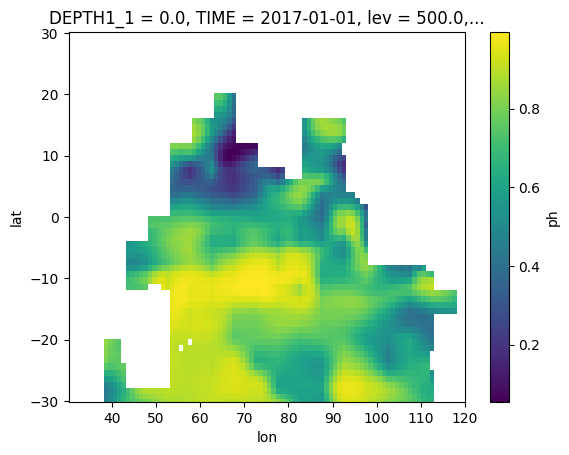

In [94]:
skill_cmems.ph.plot()

In [95]:
lat_range_as = slice(0, 30)
lon_range_as = slice(38, 78)

skill_bias_as = skill_cmems.sel(lat=lat_range_as, lon=lon_range_as).mean()
skill_bias_as.ph

<xarray.DataArray 'ph' ()> Size: 8B
array(0.42499762)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [96]:
lat_range_bob = slice(0, 30)
lon_range_bob = slice(78, 120)

skill_bias_bob = skill_cmems.sel(lat=lat_range_bob, lon=lon_range_bob).mean()
skill_bias_bob.ph

<xarray.DataArray 'ph' ()> Size: 8B
array(0.61141866)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [97]:
lat_range_cio = slice(-18, 0)
lon_range_cio = slice(30, 120)

skill_bias_cio = skill_cmems.sel(lat=lat_range_cio, lon=lon_range_cio).mean()
skill_bias_cio.ph

<xarray.DataArray 'ph' ()> Size: 8B
array(0.77371599)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [98]:
lat_range_sio = slice(-30, -18)
lon_range_sio = slice(30, 120)

skill_bias_sio = skill_cmems.sel(lat=lat_range_sio, lon=lon_range_sio).mean()
skill_bias_sio.ph

<xarray.DataArray 'ph' ()> Size: 8B
array(0.75954115)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058